## Overview
Having conducted some more research, I've found conventional DRT algorithms often use a quadratic solver to minimise a least squares problem as the following holds true:

Least squares minimisation can be made equivalent to a quadratic minimisation problem

$$ \min \{ \|\bold{R}\bold{x} - \bold{y}\|^2_2 \} = \min \{ \frac{1}{2} \bold{x}^T\bold{P}\bold{x} + \bold{q}^T\bold{x}\}$$

Where $\bold{P} = \bold{R}^T\bold{R}$, and $\bold{q}=\bold{R}^T\bold{y}$

We can try and use this method to speed up our approach

In [1]:
import numpy as np
import cvxopt as cvx
import matplotlib.pyplot as plt
import sys
try:
    import pySIMsalabim as sim
except ImportError: # add parent directory to sys.path if pySIMsalabim is not installed
    sys.path.append('../../..')
    import pySIMsalabim as sim
from pySIMsalabim.aux_funcs import time_domain_DRT as drt

In [35]:
# Proof of concept
time = np.geomspace(1e1, 1e8, 800)
tau = np.geomspace(1e1/(np.pi), 1e8, 800)
log_time = np.log10(time)
log_tau = np.log10(tau)
perfect_tau = [2e2, 5e4, 2e7]
perfect_U = [27, 25, 14]
perfect_y = drt.predict_y(time, perfect_U, perfect_tau)

In [21]:
perfect_y_scaled = (perfect_y - perfect_y.min()) / (perfect_y.max() - perfect_y.min())

Text(0.5, 0, 'log($t$) [s]')

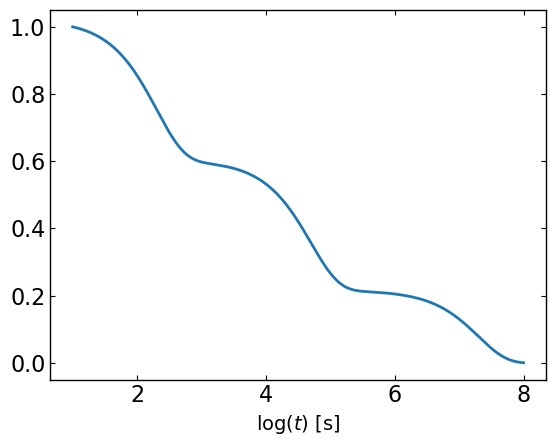

In [22]:
# Show perfect function
plt.plot(log_time, perfect_y_scaled)
plt.xlabel("log($t$) [s]")

In [127]:
# Write a function that returns ideal form
def to_quadratic_form(R, y):
    P = 2*R.T@R 
    P = (1/2)*(P.T + P)/2
    q = -2*R.T@y
    return P, q

In [139]:
R = np.exp(-np.outer(1/log_tau, log_time)).T
P, q = to_quadratic_form(R, perfect_y_scaled)
G = -np.identity(len(perfect_y_scaled))
h = np.zeros((len(perfect_y_scaled), 1))


sol = cvx.solvers.qp(cvx.matrix(P), cvx.matrix(q), cvx.matrix(G), cvx.matrix(h), solver='mosek')
x = np.array(sol['x']).flatten()

ValueError: invalid option (solver='mosek'): cvxopt.msk is not installed

In [ ]:
np.linalg.(P)

AttributeError: module 'numpy.linalg' has no attribute 'rank'

In [137]:
import qpsolvers

x = qpsolvers.solve_qp(P, q, solver='mosek')

SolverNotFound: solver 'mosek' is not in the list ['cvxopt', 'ecos', 'osqp', 'proxqp', 'quadprog', 'scs'] of available solvers

Text(0.5, 0, 'log($t$) [s]')

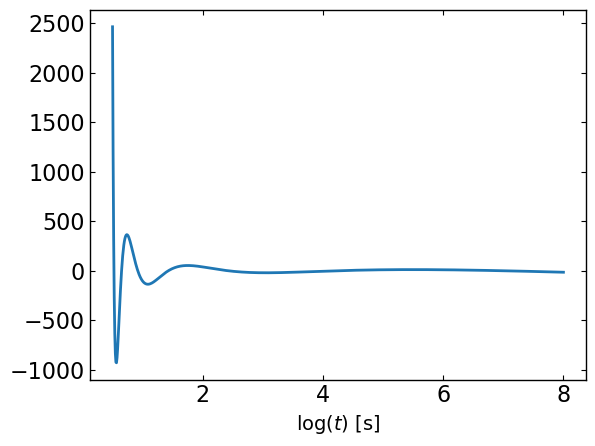

In [130]:
# Show perfect function
# plt.plot(log_time, perfect_y_scaled)
plt.plot(log_tau, x)
plt.xlabel("log($t$) [s]")